<a href="https://colab.research.google.com/github/Dockby/Student_record_Analysis/blob/main/Student_Analysis_intermediate.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


(30, 9)
student_id         object
name               object
gender             object
grade_level         int64
attendance_pct    float64
math_score          int64
english_score     float64
science_score     float64
extras             object
dtype: object
student_id        0
name              0
gender            0
grade_level       0
attendance_pct    1
math_score        0
english_score     2
science_score     1
extras            7
dtype: int64
(21, 4)
student_id        object
activity          object
hours_per_week     int64
role              object
dtype: object
student_id        0
activity          0
hours_per_week    0
role              0
dtype: int64


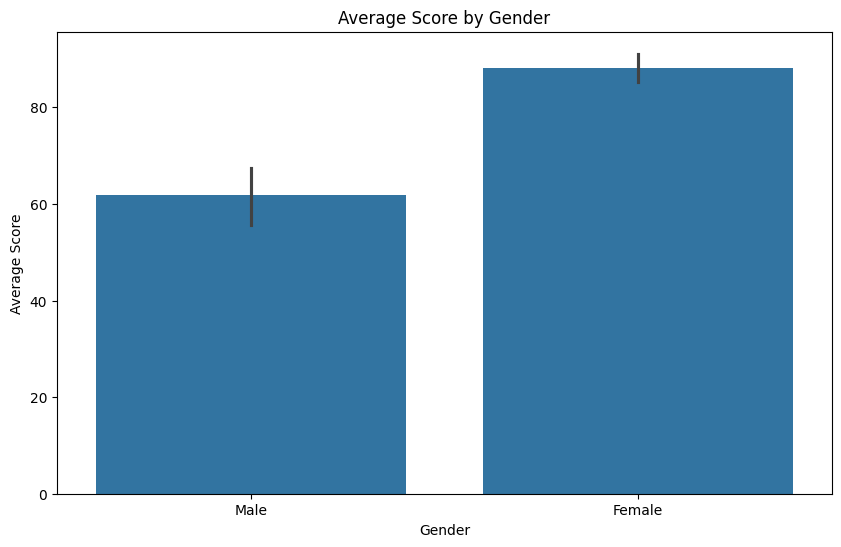

In [32]:
perf= pd.read_csv('/content/student_performance.csv')
extra= pd.read_csv("/content/student_extracurricular.csv")

print(perf.shape)
print(perf.dtypes)
print(perf.isnull().sum())
print(extra.shape)
print(extra.dtypes)
print(extra.isnull().sum())

perf['attendance_pct']=perf['attendance_pct'].fillna(perf['attendance_pct'].mean())
perf['math_score'] = perf['math_score'].fillna(perf['math_score'].mean())
perf['english_score'] = perf['english_score'].fillna(perf['english_score'].mean())
perf['science_score'] = perf['science_score'].fillna(perf['science_score'].mean())
perf['avg_score']=perf['math_score']+perf['english_score']+perf['science_score']
perf['avg_score']=perf['avg_score']/3
perf['pass_fail']=np.where(perf['avg_score']>=60,'pass','fail')
conditions = [
    perf['avg_score'] > 85,
    (perf['avg_score'] >= 60) & (perf['avg_score'] <= 84),
    perf['avg_score'] < 60
]

choices = ['High', 'Mid', 'Low']

perf['performance_tier'] = np.select(conditions, choices,default='NA')
merged_df=pd.merge(perf,extra,on='student_id',how='left')
merged_df.fillna({'hours_per_week': 0}, inplace=True)
merged_df.head()

plt.figure(figsize=(10, 6))
sns.barplot(merged_df,x="gender",y="avg_score")
plt.xlabel("Gender")
plt.ylabel("Average Score")
plt.title("Average Score by Gender")
plt.show()



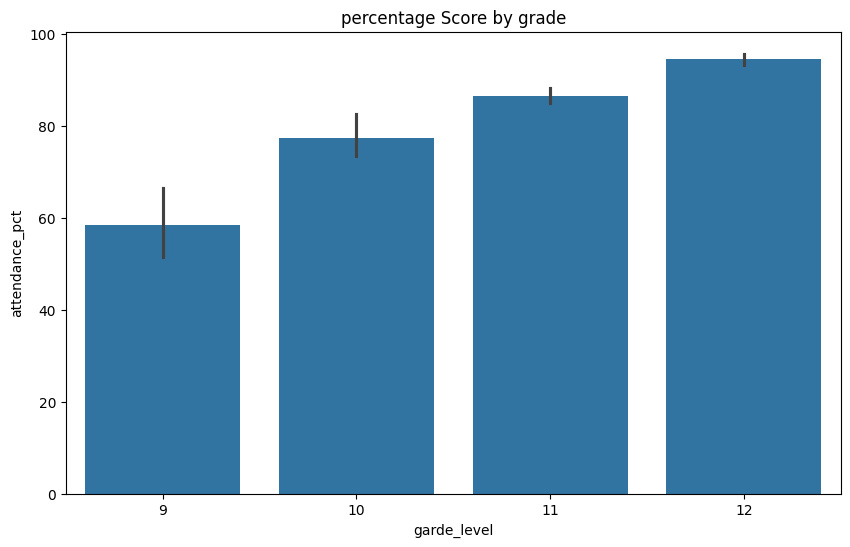

In [28]:

plt.figure(figsize=(10, 6))
sns.barplot(merged_df,x="grade_level",y="attendance_pct")
plt.xlabel("garde_level")
plt.ylabel("attendance_pct")
plt.title("percentage Score by grade")
plt.show()

<Axes: xlabel='performance_tier', ylabel='count'>

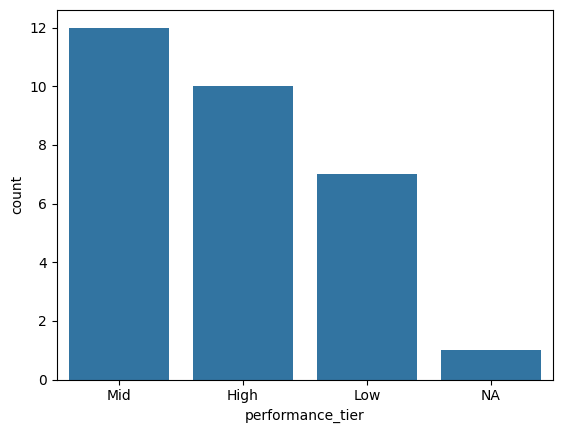

In [29]:
sns.countplot(x='performance_tier', data=merged_df)

<Axes: xlabel='attendance_pct', ylabel='avg_score'>

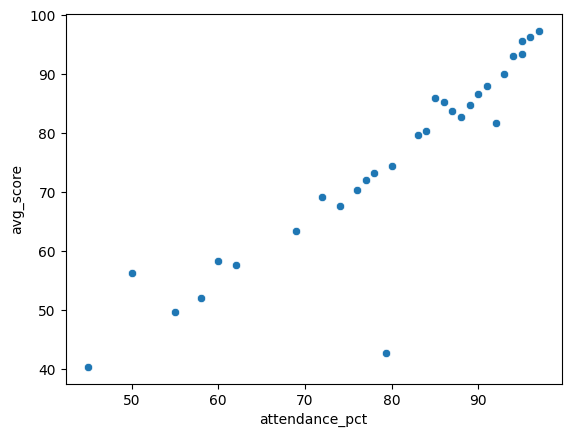

In [30]:
sns.scatterplot(x='attendance_pct', y='avg_score', data=merged_df)

In [33]:
top_performers = perf.loc[perf.groupby('grade_level')['avg_score'].idxmax(),
                           ['grade_level', 'name', 'avg_score']]
print(top_performers)

   grade_level    name  avg_score
2            9   Rohit  58.333333
0           10   Aarav  81.666667
9           11  Ananya  86.666667
7           12   Meera  97.333333
